# FactoryBench — Evaluation Analysis from Opik Traces

This notebook retrieves evaluation traces from [Opik](https://www.comet.com/opik) and generates
publication-quality figures for the FactoryBench benchmark.

In [ ]:
import os
import json
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from dotenv import load_dotenv

load_dotenv()
warnings.filterwarnings("ignore", category=FutureWarning)

# Forgis brand palette 
TIGER    = "#FF5A00"
FIRE     = "#FF4D00"
FLICKER  = "#DC4B07"
STEEL    = "#878F92"
GUNMETAL = "#122128"
PANEL    = "#202E35"
BLUE     = "#3A7BD5"
GREEN    = "#2ECC71"

MODEL_COLORS = {
    "gpt-5-mini":       TIGER,
    "claude-haiku-4-5": BLUE,
    "deepseek-v3.1":    GREEN,
    "mistral-large-3":  FLICKER,
}

FORGIS_CMAP = mcolors.LinearSegmentedColormap.from_list(
    "forgis", ["#FFFFFF", "#FFD6B8", TIGER, FLICKER, GUNMETAL],
)

FORMAT_LABELS = {
    "multiple_choice_single_select": "MCQ",
    "multiple_choice_multi_select":  "MCQ (Multi)",
    "numerical":                     "Numerical",
    "tensor":                        "Tensor",
    "ranking":                       "Ranking",
    "free_form":                     "Free Form",
}

FORMAT_ORDER  = ["MCQ", "MCQ (Multi)", "Numerical", "Tensor", "Ranking", "Free Form"]
LEVEL_ORDER   = ["level_1", "level_2", "level_3", "level_4"]
LEVEL_LABELS  = {"level_1": "L1 State", "level_2": "L2 Intervention", "level_3": "L3 Counterfactual", "level_4": "L4 Decision"}
DIFF_ORDER    = ["easy", "medium", "hard"]

FIGURES_DIR = Path("outputs/evaluation_figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def set_neurips_style():
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif", "serif"],
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "axes.linewidth": 0.8,
        "axes.edgecolor": GUNMETAL,
        "axes.labelcolor": GUNMETAL,
        "xtick.color": GUNMETAL,
        "ytick.color": GUNMETAL,
        "text.color": GUNMETAL,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": False,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
    })


set_neurips_style()
print("Setup complete.")

Setup complete.


## 1 — Fetch traces from Opik

In [ ]:
import opik

OPIK_PROJECT = os.getenv("OPIK_PROJECT_NAME")
OPIK_WORKSPACE = os.getenv("OPIK_WORKSPACE")

client = opik.Opik(
    project_name=OPIK_PROJECT,
    workspace=OPIK_WORKSPACE,
)

print(f"Connected to Opik project='{OPIK_PROJECT}' workspace='{OPIK_WORKSPACE}'")
print("Fetching traces (this may take a moment)...")

traces = client.search_traces(
    project_name=OPIK_PROJECT, max_results=100000, filter_string='start_time > "2026-04-17T03:58:00Z"'
)

print(f"Fetched {len(traces)} traces.")

c:\Users\Coral\Documents\Forgis\new_FactoryBench\FactoryBench\.venv\Lib\site-packages\opik\rest_api\core\pydantic_utilities.py:13: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.datetime_parse import parse_date as parse_date


Connected to Opik project='FactoryBench' workspace='forgis'
Fetching traces (this may take a moment)...
Fetched 193 traces.


## 2 — Build a DataFrame from traces

In [3]:
rows = []

for trace in traces:
    metadata = trace.metadata or {}
    tags = set(trace.tags or [])
    feedback = {fb.name: fb.value for fb in (trace.feedback_scores or [])}
    inp = trace.input or {}

    model_name = (metadata.get("model") or "unknown").lower()

    answer_format_raw = metadata.get("answer_format", "unknown")
    answer_format = FORMAT_LABELS.get(answer_format_raw, answer_format_raw)

    # Derive level from tags
    level = "unknown"
    for tag in tags:
        if tag.startswith("level_"):
            level = tag
            break

    # Derive difficulty from tags or metadata
    difficulty = ""
    for d in DIFF_ORDER:
        if d in tags:
            difficulty = d
            break

    accuracy = feedback.get("accuracy")
    llm_judge = feedback.get("llm_judge")

    rows.append({
        "trace_id":      trace.id,
        "model":         model_name,
        "level":         level,
        "answer_format": answer_format,
        "difficulty":    difficulty,
        "question_type": metadata.get("question_type", "unknown"),
        "dataset":       metadata.get("dataset", ""),
        "episode":       metadata.get("episode", ""),
        "accuracy":      accuracy,
        "llm_judge":     llm_judge,
        "prediction":    inp.get("prediction", ""),
        "ground_truth":  inp.get("ground_truth", ""),
        "cost":          trace.total_estimated_cost or 0.0,
    })

df = pd.DataFrame(rows)

# Drop rows without a score
df = df.dropna(subset=["accuracy"])
df["accuracy"] = df["accuracy"].astype(float)

print(f"DataFrame shape: {df.shape}")
print(f"Models:  {sorted(df['model'].unique())}")
print(f"Levels:  {sorted(df['level'].unique())}")
print(f"Formats: {sorted(df['answer_format'].unique())}")
if df['difficulty'].any():
    print(f"Difficulties: {sorted(df[df['difficulty'] != '']['difficulty'].unique())}")
df.head()

DataFrame shape: (193, 13)
Models:  ['claude-haiku-4-5-20251001', 'gpt-5-mini', 'gpt-5-mini-2025-08-07']
Levels:  ['level_1']
Formats: ['MCQ', 'MCQ (Multi)', 'Numerical', 'Ranking', 'Tensor']


,trace_id,model,level,answer_format,difficulty,question_type,dataset,episode,accuracy,llm_judge,prediction,ground_truth,cost
0,019d9a54-bffd-7a97-9b93-84ad6047cd19,claude-haiku-4-5-20251001,level_1,Ranking,,state_joint_speed_ranking,aursad,aursad_016,1.0,None,I need to find the absolute speeds for joints ...,BDCA,0.0
1,019d9a54-b464-746a-91f8-5174b9429148,claude-haiku-4-5-20251001,level_1,Tensor,,state_acceleration,aursad,aursad_017,0.0,None,-9.6_0.02_0.23,-94.14_0.19_2.25,0.0
2,019d9a54-abf4-721c-b600-1182659f2af5,claude-haiku-4-5-20251001,level_1,MCQ,,state_external_force_detected,aursad,aursad_024,1.0,None,"To answer this question, I need to find data a...",B,0.0
3,019d9a54-9819-7f62-9d51-33c0f296cc88,claude-haiku-4-5-20251001,level_1,Ranking,,state_joint_speed_ranking,aursad,aursad_020,1.0,None,I need to find the absolute speeds of joints 0...,CDAB,0.0
4,019d9a54-8bd9-757f-9306-cddee529f948,claude-haiku-4-5-20251001,level_1,Tensor,,state_acceleration,aursad,aursad_005,0.0,None,-9.56_0.06_0.13,-93.76_0.56_1.32,0.0


## 3 — Heatmap: Models × Levels

In [4]:
def plot_heatmap(pivot_df, title, xlabel, ylabel, filename, col_labels=None, figsize=None):
    """Generic heatmap with count annotations."""
    if pivot_df.empty:
        print(f"Skipping {title}: no data.")
        return

    n_rows, n_cols = pivot_df.shape
    if figsize is None:
        figsize = (max(6, n_cols * 1.8), max(3, n_rows * 1.2 + 1))

    # Build annotation matrix with counts
    annot = pivot_df.copy().astype(object)
    for model in pivot_df.index:
        for col in pivot_df.columns:
            val = pivot_df.loc[model, col]
            mask = (df["model"] == model)
            if col in LEVEL_LABELS.values():
                # Reverse lookup level key
                level_key = [k for k, v in LEVEL_LABELS.items() if v == col]
                if level_key:
                    mask = mask & (df["level"] == level_key[0])
            elif col in FORMAT_ORDER:
                mask = mask & (df["answer_format"] == col)
            elif col in DIFF_ORDER:
                mask = mask & (df["difficulty"] == col)
            n = mask.sum()
            if pd.isna(val):
                annot.loc[model, col] = ""
            else:
                annot.loc[model, col] = f"{val:.1f}\n(n={n})"

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        pivot_df.values.astype(float),
        annot=annot.values,
        fmt="",
        cmap=FORGIS_CMAP,
        vmin=0, vmax=100,
        linewidths=1.5, linecolor="white",
        cbar_kws={"label": "Accuracy (%)", "shrink": 0.8},
        ax=ax,
        mask=pd.isna(pivot_df.values.astype(float)),
        xticklabels=col_labels if col_labels else pivot_df.columns.tolist(),
        yticklabels=pivot_df.index.tolist(),
    )
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontweight="bold")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight="bold", pad=14)
    fig.tight_layout()
    out = FIGURES_DIR / filename
    fig.savefig(out, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")

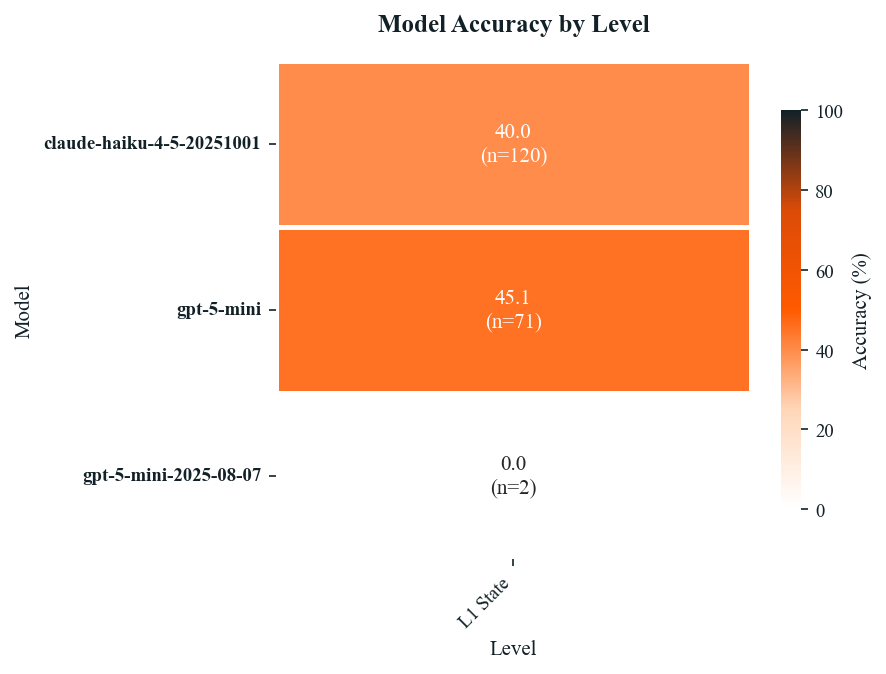

Saved: outputs\evaluation_figures\heatmap_models_x_levels.png


In [5]:
# Heatmap 1: Models × Levels
pivot_levels = df.groupby(["model", "level"])["accuracy"].mean().unstack() * 100

# Reorder columns
level_cols = [l for l in LEVEL_ORDER if l in pivot_levels.columns]
pivot_levels = pivot_levels[level_cols]
pivot_levels.columns = [LEVEL_LABELS.get(c, c) for c in pivot_levels.columns]

plot_heatmap(
    pivot_levels,
    title="Model Accuracy by Level",
    xlabel="Level",
    ylabel="Model",
    filename="heatmap_models_x_levels.png",
)

## 4 — Heatmap: Models × Answer Formats

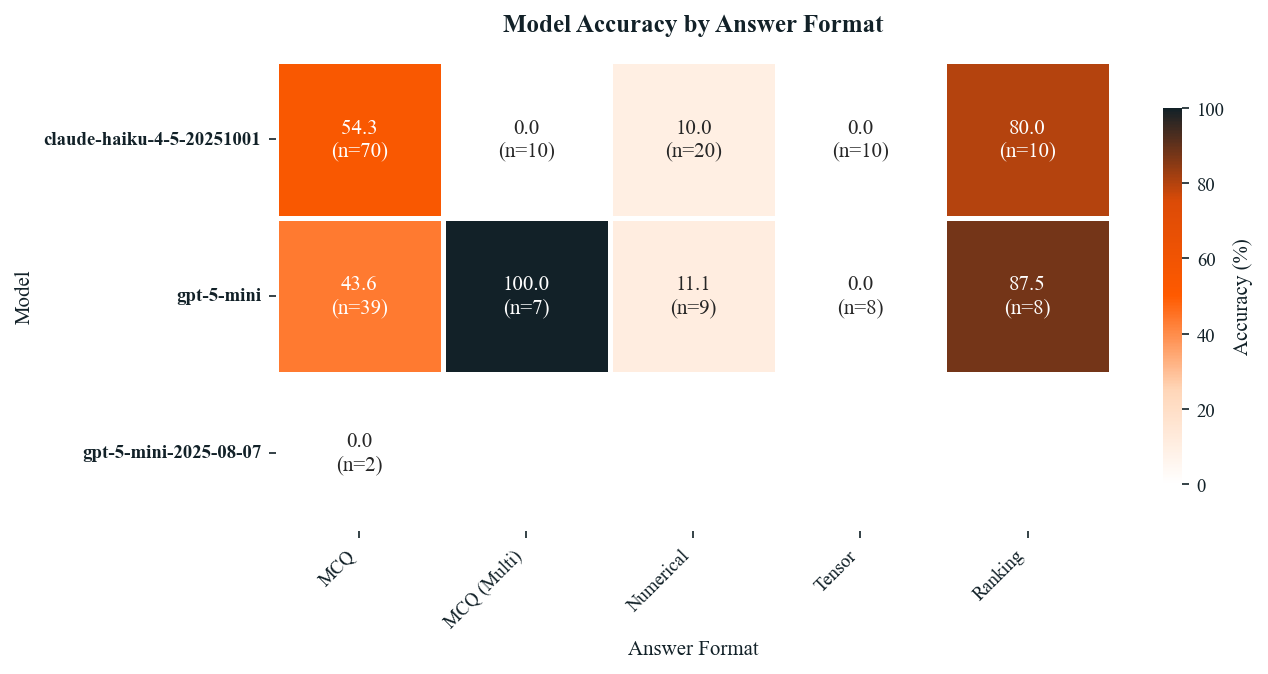

Saved: outputs\evaluation_figures\heatmap_models_x_formats.png


In [6]:
pivot_formats = df.groupby(["model", "answer_format"])["accuracy"].mean().unstack() * 100

fmt_cols = [f for f in FORMAT_ORDER if f in pivot_formats.columns]
extra = sorted(set(pivot_formats.columns) - set(FORMAT_ORDER))
pivot_formats = pivot_formats[fmt_cols + extra]

plot_heatmap(
    pivot_formats,
    title="Model Accuracy by Answer Format",
    xlabel="Answer Format",
    ylabel="Model",
    filename="heatmap_models_x_formats.png",
)

## 5 — ROC-style Curve (Score Distribution / Threshold Sweep)

Since FactoryBench scoring is not binary classification, we produce a
**threshold–accuracy curve**: for each threshold *t* in [0, 1], we report
the fraction of predictions whose score ≥ *t*.

This shows how each model's score distribution degrades as we raise the
acceptance bar, analogous to a ROC curve.

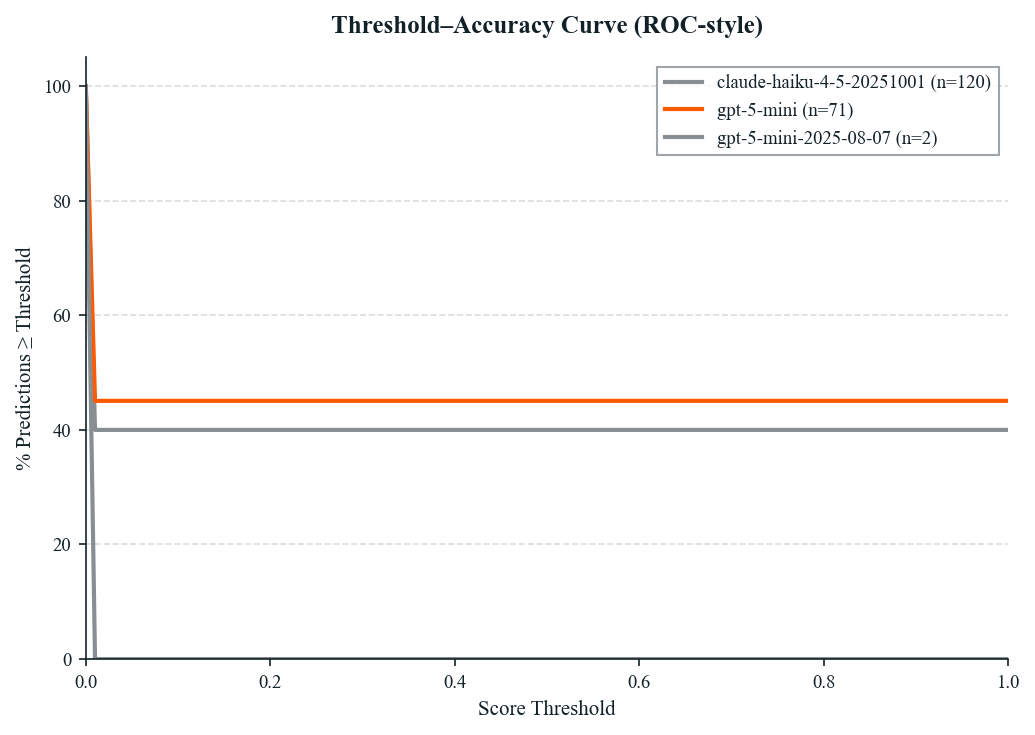

Saved: outputs\evaluation_figures\roc_threshold_curve.png


In [7]:
thresholds = np.linspace(0, 1, 101)
models = sorted(df["model"].unique())

fig, ax = plt.subplots(figsize=(7, 5))

for model in models:
    scores = df.loc[df["model"] == model, "accuracy"].values
    if len(scores) == 0:
        continue
    fractions = [(scores >= t).mean() * 100 for t in thresholds]
    color = MODEL_COLORS.get(model, STEEL)
    ax.plot(thresholds, fractions, label=f"{model} (n={len(scores)})", color=color, linewidth=2)

ax.set_xlabel("Score Threshold")
ax.set_ylabel("% Predictions ≥ Threshold")
ax.set_title("Threshold–Accuracy Curve (ROC-style)", fontweight="bold", pad=12)
ax.set_xlim(0, 1)
ax.set_ylim(0, 105)
ax.legend(loc="upper right", frameon=True, fancybox=False, edgecolor=STEEL)
ax.yaxis.grid(True, linestyle="--", alpha=0.3, color=STEEL)
ax.set_axisbelow(True)
fig.tight_layout()
out = FIGURES_DIR / "roc_threshold_curve.png"
fig.savefig(out, bbox_inches="tight")
plt.show()
print(f"Saved: {out}")

### 5b — ROC-style Curve per Answer Format

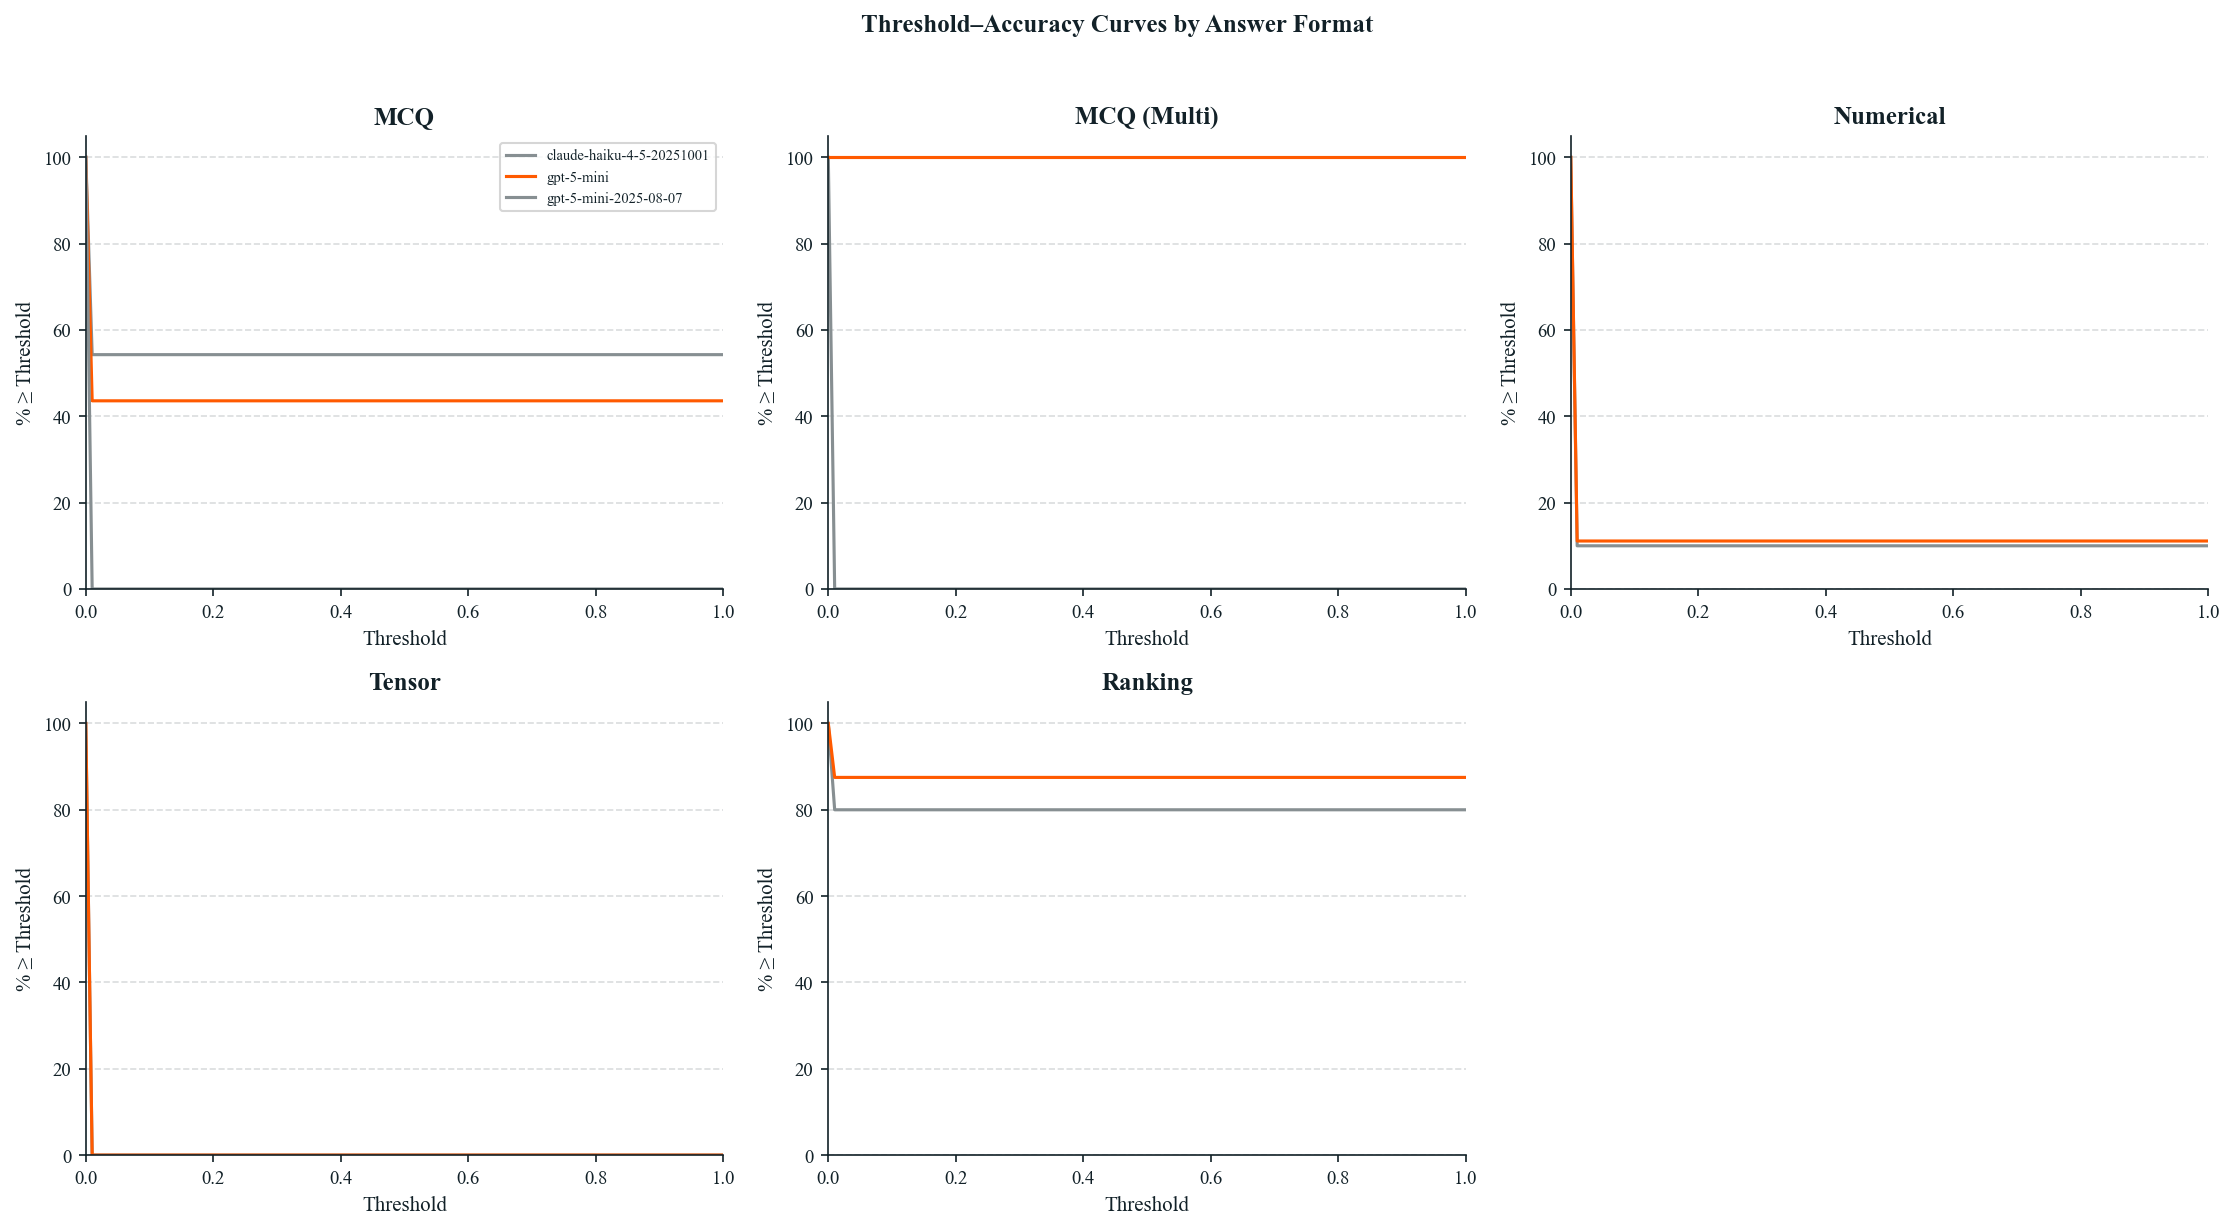

Saved: outputs\evaluation_figures\roc_threshold_by_format.png


In [8]:
formats_present = [f for f in FORMAT_ORDER if f in df["answer_format"].unique()]
n_fmts = len(formats_present)

if n_fmts > 0:
    n_cols = min(3, n_fmts)
    n_rows = (n_fmts + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)

    for idx, fmt in enumerate(formats_present):
        ax = axes[idx // n_cols][idx % n_cols]
        df_fmt = df[df["answer_format"] == fmt]
        for model in models:
            scores = df_fmt.loc[df_fmt["model"] == model, "accuracy"].values
            if len(scores) == 0:
                continue
            fractions = [(scores >= t).mean() * 100 for t in thresholds]
            color = MODEL_COLORS.get(model, STEEL)
            ax.plot(thresholds, fractions, label=model, color=color, linewidth=1.5)
        ax.set_title(fmt, fontweight="bold")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 105)
        ax.set_xlabel("Threshold")
        ax.set_ylabel("% ≥ Threshold")
        ax.yaxis.grid(True, linestyle="--", alpha=0.3, color=STEEL)

    # Hide empty subplots
    for idx in range(n_fmts, n_rows * n_cols):
        axes[idx // n_cols][idx % n_cols].set_visible(False)

    axes[0][0].legend(fontsize=7, loc="upper right")
    fig.suptitle("Threshold–Accuracy Curves by Answer Format", fontweight="bold", y=1.02)
    fig.tight_layout()
    out = FIGURES_DIR / "roc_threshold_by_format.png"
    fig.savefig(out, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")
else:
    print("No answer formats found — skipping.")

## 7 — Benchmark Table (Model × Level × Answer Format)

In [9]:
# Build a multi-level column table: (level, answer_format) with accuracy
table_data = []

for model in sorted(df["model"].unique()):
    row = {"Model": model}
    df_m = df[df["model"] == model]

    for level_key in LEVEL_ORDER:
        level_label = LEVEL_LABELS.get(level_key, level_key)
        df_ml = df_m[df_m["level"] == level_key]

        # Per-format accuracy
        for fmt in FORMAT_ORDER:
            df_mlf = df_ml[df_ml["answer_format"] == fmt]
            if len(df_mlf) > 0:
                acc = df_mlf["accuracy"].mean() * 100
                row[(level_label, fmt)] = f"{acc:.1f} (n={len(df_mlf)})"
            else:
                row[(level_label, fmt)] = "—"

        # Total for this level
        if len(df_ml) > 0:
            acc = df_ml["accuracy"].mean() * 100
            row[(level_label, "Total")] = f"{acc:.1f} (n={len(df_ml)})"
        else:
            row[(level_label, "Total")] = "—"

    # Overall total
    row[("Overall", "Total")] = f"{df_m['accuracy'].mean() * 100:.1f} (n={len(df_m)})"

    table_data.append(row)

# Build DataFrame with MultiIndex columns
model_col = [r["Model"] for r in table_data]

multi_cols = []
for level_key in LEVEL_ORDER:
    level_label = LEVEL_LABELS.get(level_key, level_key)
    for fmt in FORMAT_ORDER + ["Total"]:
        multi_cols.append((level_label, fmt))
multi_cols.append(("Overall", "Total"))

table_rows = []
for r in table_data:
    table_rows.append([r.get(col, "—") for col in multi_cols])

col_index = pd.MultiIndex.from_tuples(multi_cols, names=["Level", "Format"])
benchmark_table = pd.DataFrame(table_rows, index=model_col, columns=col_index)
benchmark_table.index.name = "Model"

# Drop columns that are entirely "—"
mask = benchmark_table.ne("—").any(axis=0)
benchmark_table = benchmark_table.loc[:, mask]

benchmark_table

Level                         L1 State                                        \
Format                             MCQ  MCQ (Multi)    Numerical      Tensor   
Model                                                                          
claude-haiku-4-5-20251001  54.3 (n=70)   0.0 (n=10)  10.0 (n=20)  0.0 (n=10)   
gpt-5-mini                 43.6 (n=39)  100.0 (n=7)   11.1 (n=9)   0.0 (n=8)   
gpt-5-mini-2025-08-07        0.0 (n=2)            —            —           —   

Level                                                      Overall  
Format                         Ranking         Total         Total  
Model                                                               
claude-haiku-4-5-20251001  80.0 (n=10)  40.0 (n=120)  40.0 (n=120)  
gpt-5-mini                  87.5 (n=8)   45.1 (n=71)   45.1 (n=71)  
gpt-5-mini-2025-08-07                —     0.0 (n=2)     0.0 (n=2)

In [10]:
# Save table as LaTeX and CSV
latex_out = FIGURES_DIR / "benchmark_table.tex"
csv_out   = FIGURES_DIR / "benchmark_table.csv"

benchmark_table.to_latex(latex_out, multicolumn=True, multirow=True, escape=False)
benchmark_table.to_csv(csv_out)

print(f"LaTeX table saved: {latex_out}")
print(f"CSV table saved:   {csv_out}")

LaTeX table saved: outputs\evaluation_figures\benchmark_table.tex
CSV table saved:   outputs\evaluation_figures\benchmark_table.csv


## 7b — Render table as a figure

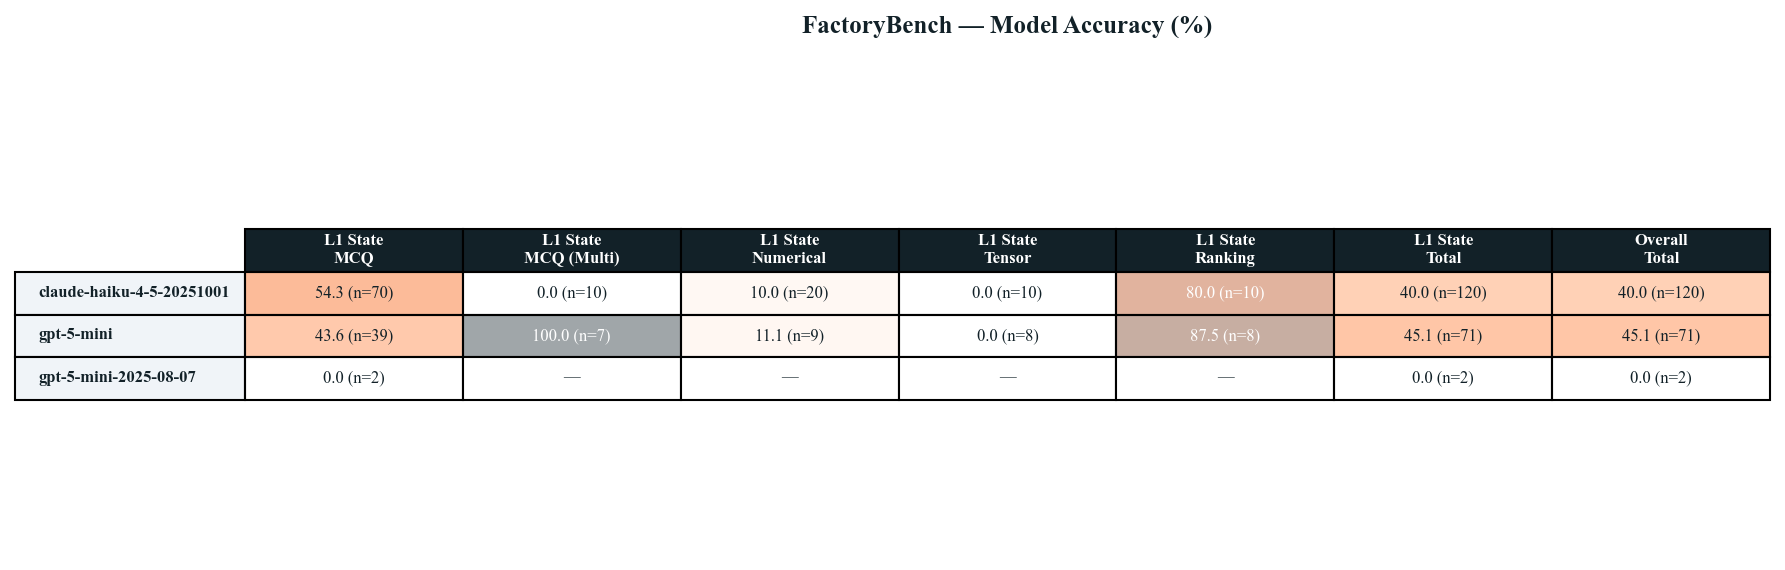

Saved: outputs\evaluation_figures\benchmark_table_figure.png


In [11]:
def render_table_figure(bench_df, filename):
    """Render the benchmark table as a matplotlib figure for the paper."""
    flat = bench_df.copy()
    flat.columns = [f"{l}\n{f}" for l, f in flat.columns]

    n_cols = len(flat.columns)
    n_rows = len(flat)

    fig, ax = plt.subplots(figsize=(max(12, n_cols * 1.6), max(2, n_rows * 0.8 + 1.5)))
    ax.axis("off")

    tbl = ax.table(
        cellText=flat.values,
        rowLabels=flat.index,
        colLabels=flat.columns,
        cellLoc="center",
        loc="center",
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8)
    tbl.scale(1.0, 1.6)

    # Style header
    for (row, col), cell in tbl.get_celld().items():
        if row == 0:
            cell.set_facecolor(GUNMETAL)
            cell.set_text_props(color="white", fontweight="bold")
        elif col == -1:
            cell.set_facecolor("#F0F4F8")
            cell.set_text_props(fontweight="bold")
        else:
            text = cell.get_text().get_text()
            if text != "—":
                try:
                    val = float(text.split("(")[0].strip())
                    norm = val / 100.0
                    r, g, b, _ = FORGIS_CMAP(norm)
                    lum = 0.299 * r + 0.587 * g + 0.114 * b
                    cell.set_facecolor((r, g, b, 0.4))
                    if lum < 0.4:
                        cell.set_text_props(color="white")
                except (ValueError, IndexError):
                    pass

    ax.set_title("FactoryBench — Model Accuracy (%)", fontweight="bold", fontsize=12, pad=20)
    fig.tight_layout()
    out = FIGURES_DIR / filename
    fig.savefig(out, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")


render_table_figure(benchmark_table, "benchmark_table_figure.png")

## 9 — Summary statistics

In [12]:
print("=" * 60)
print("Summary")
print("=" * 60)
print(f"Total traces with scores: {len(df)}")
print(f"Models evaluated:         {sorted(df['model'].unique())}")
print(f"Levels covered:           {sorted(df['level'].unique())}")
print(f"Answer formats:           {sorted(df['answer_format'].unique())}")
print(f"Total estimated cost:     ${df['cost'].sum():.4f}")
print()

# Per-model summary
summary = df.groupby("model").agg(
    n=("accuracy", "count"),
    mean_accuracy=("accuracy", "mean"),
    std_accuracy=("accuracy", "std"),
    cost=("cost", "sum"),
).reset_index()
summary["mean_accuracy"] = (summary["mean_accuracy"] * 100).round(2)
summary["std_accuracy"]  = (summary["std_accuracy"] * 100).round(2)
summary["cost"]          = summary["cost"].round(4)
summary.columns = ["Model", "N", "Acc (%)", "Std (%)", "Cost ($)"]
summary

Summary
Total traces with scores: 193
Models evaluated:         ['claude-haiku-4-5-20251001', 'gpt-5-mini', 'gpt-5-mini-2025-08-07']
Levels covered:           ['level_1']
Answer formats:           ['MCQ', 'MCQ (Multi)', 'Numerical', 'Ranking', 'Tensor']
Total estimated cost:     $0.0000



,Model,N,Acc (%),Std (%),Cost ($)
0,claude-haiku-4-5-20251001,120,40.00,49.20,0.0
1,gpt-5-mini,71,45.07,50.11,0.0
2,gpt-5-mini-2025-08-07,2,0.00,0.00,0.0


---

## Appendix: Accuracy Calculation Methodology

### Scoring rules by answer format

Each prediction is scored on a **0.0 – 1.0** scale. The scoring rule depends on the
`answer_format` of the question:

| Format | Scoring Method | Details |
|--------|---------------|----------|
| **`multiple_choice_single_select`** | Exact letter match | Extract last A–D from model response, compare to ground truth. **1.0** if match, **0.0** otherwise. |
| **`multiple_choice_multi_select`** | Per-position T/F match | Model must output a string of T/F characters (e.g. `TFFT`). **1.0** if all positions match, **0.5** if off-by-one, **0.0** otherwise. |
| **`numerical`** | Tolerance-based | Exact match within an acceptance margin (question-specific `margin` or default `1e-4`). **1.0** if within tolerance, **0.0** otherwise. |
| **`tensor`** | Per-element tolerance | Each element checked against its margin. Score = fraction of elements within tolerance. |
| **`ranking`** | Permutation match | Regex extracts a 4-letter permutation (e.g. `DCAB`). **1.0** if exact match, **0.0** otherwise. |
| **`free_form`** | LLM-as-Judge | A judge model (default: `gpt-5-mini`) scores the prediction 0–10 against the reference, normalised to 0.0–1.0. |

### LLM-as-Judge protocol

For `free_form` questions (Level 4), the judge receives:
- The original question
- The reference (ground-truth) answer
- The model's prediction

Scoring rubric (0–10):

| Score | Meaning |
|-------|----------|
| 10 | Semantically equivalent: direction, signal, magnitude, timing correct |
| 7 | Main trend correct but imprecise on magnitude or timing |
| 4 | Right signal but partially incorrect behaviour |
| 1 | On-topic but mostly incorrect |
| 0 | Completely wrong, irrelevant, or refuses to answer |

The raw 0–10 score is normalised to \[0.0, 1.0\] and logged as both `llm_judge` and
`accuracy` feedback scores.

### Aggregation

- **Cell accuracy** = arithmetic mean of all per-question scores in that cell.
- **Total (per level)** = mean of all scores at that level, regardless of format.
- **Overall** = mean of all scores for that model.
- Sample counts are shown as `(n=...)` in every cell and heatmap annotation.

### Threshold–Accuracy (ROC-style) curve

For each threshold $t \in [0, 1]$, the curve plots the fraction of predictions
scoring $\geq t$. A model whose curve stays high across thresholds has a stronger
concentration of high-confidence correct answers.

### Notes

- Difficulty labels (`easy`, `medium`, `hard`) are only available for Levels 2 and 3.
- Level 1 questions are unlabelled for difficulty.
- Level 4 (`free_form`) is evaluated exclusively via the LLM-as-Judge protocol.